# PinCode Clustering for Bihar


#### Importing Libraries


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [41]:
postal_records = pd.read_csv("clustering_data.csv", low_memory=False)
display(postal_records.head())
print(f"Total rows in dataset: {len(postal_records):,}")


,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
0,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Peddakotla B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.5689,77.85624
1,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Pinnadhari B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.5281,77.857014
2,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Yerraguntapalle B.O,515631,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.561111,77.85715
3,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Obulareddipalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.2488,78.2588
4,Andhra Pradesh Circle,Kurnool Region,Hindupur Division,Odulapalli B.O,515581,BO,Delivery,ANANTAPUR,ANDHRA PRADESH,14.24555,78.2477


Total rows in dataset: 157,126


#### Filtering Bihar Data


In [42]:
bihar_records = postal_records[
    postal_records["StateName"].astype(str).str.upper() == "BIHAR"
].copy()

display(bihar_records.head())
print(f"Rows for Bihar: {len(bihar_records):,}")
print(f"Unique districts: {bihar_records['District'].nunique()}")
print(f"Unique pincodes: {bihar_records['Pincode'].nunique()}")


,CircleName,RegionName,DivisionName,OfficeName,Pincode,OfficeType,Delivery,District,StateName,Latitude,Longitude
33,Bihar Circle,"East Region, Bhagalpur",Bhagalpur Division,Kathrang BO,813105,BO,Delivery,BANKA,BIHAR,84.527,24.239
34,Bihar Circle,"East Region, Bhagalpur",Bhagalpur Division,Mohiuddivpur BO,813105,BO,Delivery,BHAGALPUR,BIHAR,84.529,24.2354
35,Bihar Circle,"East Region, Bhagalpur",Bhagalpur Division,Sanjha BO,813105,BO,Delivery,BANKA,BIHAR,84.52367,24.2365
36,Bihar Circle,"East Region, Bhagalpur",Bhagalpur Division,Singhnan BO,813105,BO,Delivery,BANKA,BIHAR,84.535,24.2236
37,Bihar Circle,"East Region, Bhagalpur",Bhagalpur Division,Kasri BO,813203,BO,Delivery,BHAGALPUR,BIHAR,87.2628853,25.2987632


Rows for Bihar: 9,113
Unique districts: 38
Unique pincodes: 857


In [53]:
missing = bihar_records[["Latitude", "Longitude"]].isnull().sum()
missing


Latitude     25
Longitude    25
dtype: int64

#### Cleaning the Coordinates


In [62]:
def prepare_bihar_coordinates(source_frame):
    frema = source_frame.copy()
    frema["Latitude"] = pd.to_numeric(frema["Latitude"], errors="coerce")
    frema["Longitude"] = pd.to_numeric(frema["Longitude"], errors="coerce")
    frema = frema.dropna(subset=["Latitude", "Longitude"]).copy()

    bihar_latitude_range = (24.0, 28.5)
    bihar_longitude_range = (82.0, 89.5)

    correct_order_mask = (frema["Latitude"].between(*bihar_latitude_range)& frema["Longitude"].between(*bihar_longitude_range))
    swapped_order_mask = (frema["Longitude"].between(*bihar_latitude_range) & frema["Latitude"].between(*bihar_longitude_range))

    usable_rows = frema[correct_order_mask | swapped_order_mask].copy()
    usable_rows["geo_latitude"] = np.where(correct_order_mask.loc[usable_rows.index], usable_rows["Latitude"], usable_rows["Longitude"],)
    usable_rows["geo_longitude"] = np.where(
        correct_order_mask.loc[usable_rows.index],
        usable_rows["Longitude"],
        usable_rows["Latitude"],
    )

    usable_rows = usable_rows.drop_duplicates(
        subset=["Pincode", "geo_latitude", "geo_longitude"]
    ).reset_index(drop=True)

    return usable_rows, int(correct_order_mask.sum()), int(swapped_order_mask.sum())

clean_bihar_records, regular_coordinate_rows, swapped_coordinate_rows = prepare_bihar_coordinates(bihar_records)

display(
    clean_bihar_records[
        ["OfficeName", "District", "Pincode", "geo_latitude", "geo_longitude"]
    ].head()
)
print(f"Rows after cleaning: {len(clean_bihar_records):,}")
print(f"Coordinates already in correct order: {regular_coordinate_rows:,}")
print(f"Coordinates fixed from swapped order: {swapped_coordinate_rows:,}")


,OfficeName,District,Pincode,geo_latitude,geo_longitude
0,Kathrang BO,BANKA,813105,24.239000,84.527000
1,Mohiuddivpur BO,BHAGALPUR,813105,24.235400,84.529000
2,Sanjha BO,BANKA,813105,24.236500,84.523670
3,Singhnan BO,BANKA,813105,24.223600,84.535000
4,Kasri BO,BHAGALPUR,813203,25.298763,87.262885


Rows after cleaning: 4,959
Coordinates already in correct order: 7,851
Coordinates fixed from swapped order: 692


In [55]:
geo_points = clean_bihar_records[["geo_longitude", "geo_latitude"]].to_numpy(dtype=float)
point_longitudes = geo_points[:, 0]
point_latitudes = geo_points[:, 1]

print(f"Longitude range: {point_longitudes.min()} to {point_longitudes.max()}")
print(f"Latitude range: {point_latitudes.min()} to {point_latitudes.max()}")


Longitude range: 82.01619 to 89.441605
Latitude range: 24.0 to 28.369


#### Visualizing the Bihar Locations


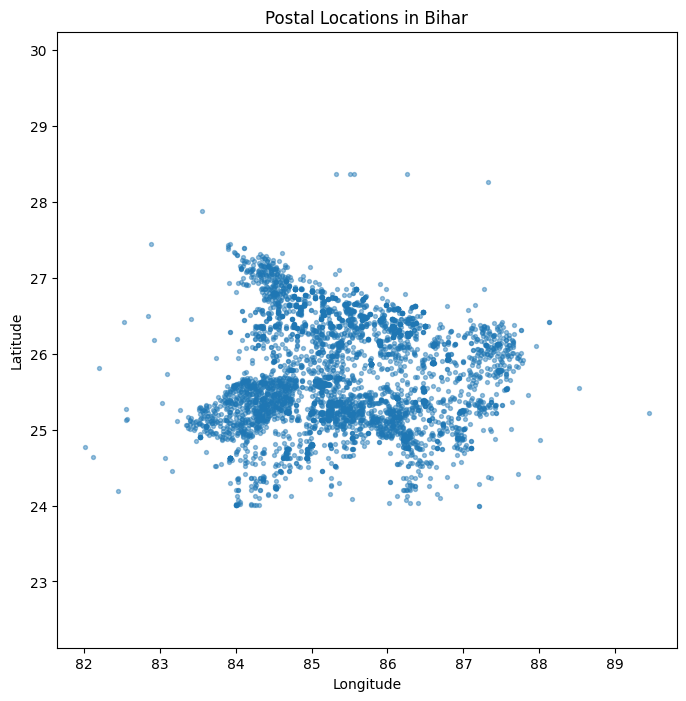

In [56]:
plt.figure(figsize=(8, 8))
plt.scatter(point_longitudes, point_latitudes, s=8, alpha=0.45)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Postal Locations in Bihar")
plt.axis("equal")
plt.show()


#### K-Means Clustering From Scratch


In [57]:
class SpatialKMeans:
    def __init__(self, cluster_total=3, max_rounds=300, random_seed=42):
        self.cluster_total = cluster_total
        self.max_rounds = max_rounds
        self.random_seed = random_seed
        self.centers = None
        self.labels = None
        self.inertia_ = None

    def fit(self, point_matrix):
        random_generator = np.random.default_rng(self.random_seed)
        starting_ids = random_generator.choice(
            len(point_matrix), size=self.cluster_total, replace=False
        )
        center_matrix = point_matrix[starting_ids].copy()

        for _ in range(self.max_rounds):
            distance_matrix = np.linalg.norm(
                point_matrix[:, np.newaxis, :] - center_matrix[np.newaxis, :, :],
                axis=2,
            )
            nearest_center = distance_matrix.argmin(axis=1)

            updated_centers = np.array([
                point_matrix[nearest_center == cluster_id].mean(axis=0)
                if np.any(nearest_center == cluster_id)
                else center_matrix[cluster_id]
                for cluster_id in range(self.cluster_total)
            ])

            if np.allclose(center_matrix, updated_centers):
                center_matrix = updated_centers
                break

            center_matrix = updated_centers

        final_distances = np.linalg.norm(
            point_matrix[:, np.newaxis, :] - center_matrix[np.newaxis, :, :],
            axis=2,
        )
        final_labels = final_distances.argmin(axis=1)
        nearest_distances = final_distances[np.arange(len(point_matrix)), final_labels]

        self.centers = center_matrix
        self.labels = final_labels
        self.inertia_ = float(np.sum(nearest_distances ** 2))
        return self

    def predict(self, point_matrix):
        distance_matrix = np.linalg.norm(
            point_matrix[:, np.newaxis, :] - self.centers[np.newaxis, :, :],
            axis=2,
        )
        return distance_matrix.argmin(axis=1)


#### Elbow Method


In [58]:
candidate_k_values = range(1, 11)
inertia_scores = []

for cluster_total in candidate_k_values:
    trial_clusterer = SpatialKMeans(
        cluster_total=cluster_total,
        max_rounds=500,
        random_seed=42,
    )
    trial_clusterer.fit(geo_points)
    inertia_scores.append(trial_clusterer.inertia_)

elbow_table = pd.DataFrame({
    "k": list(candidate_k_values),
    "inertia": inertia_scores,
})
display(elbow_table)


,k,inertia
0,1,7239.468130
1,2,3911.798599
2,3,2558.671112
3,4,1945.740384
4,5,1465.267751
5,6,1413.154050
6,7,1019.196968
7,8,882.458633
8,9,824.298319
9,10,728.914850


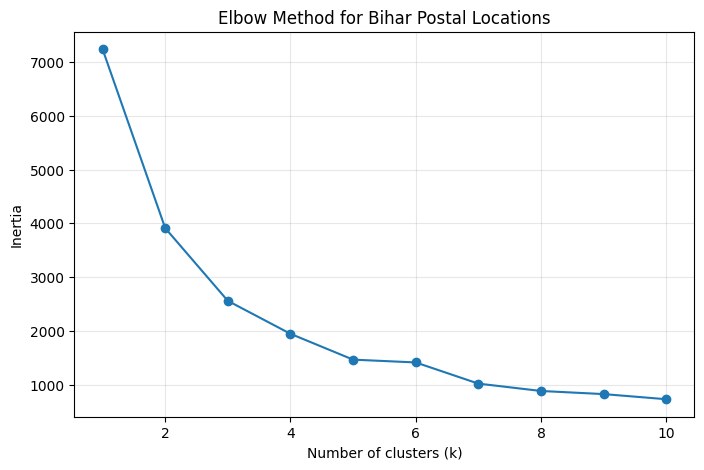

In [59]:
plt.figure(figsize=(8, 5))
plt.plot(list(candidate_k_values), inertia_scores, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Bihar Postal Locations")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
total = 5

bihar_clusterer = SpatialKMeans(
    cluster_total=total,
    max_rounds=500,
    random_seed=42,
)
bihar_clusterer.fit(geo_points)

cluster_tags = bihar_clusterer.labels
hub_locations = bihar_clusterer.centers

hub_summary = pd.DataFrame(
    hub_locations,
    columns=["hub_longitude", "hub_latitude"],
).sort_values(["hub_latitude", "hub_longitude"]).reset_index(drop=True)

display(hub_summary)


,hub_longitude,hub_latitude
0,85.571891,25.187272
1,84.255087,25.188257
2,87.005658,25.620565
3,85.836681,26.316756
4,84.686784,26.621737


#### Final Cluster Plot


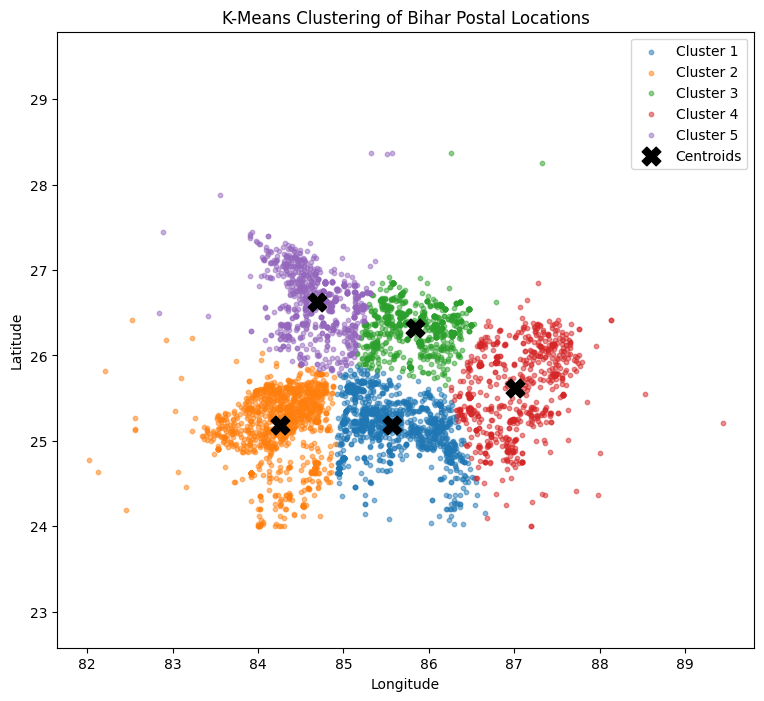

In [61]:
plt.figure(figsize=(9, 8))
for cluster_id in range(chosen_cluster_total):
    cluster_slice = geo_points[cluster_tags == cluster_id]
    plt.scatter(
        cluster_slice[:, 0],
        cluster_slice[:, 1],
        s=10,
        alpha=0.5,
        label=f"Cluster {cluster_id + 1}",
    )

plt.scatter(
    hub_locations[:, 0],
    hub_locations[:, 1],
    c="black",
    marker="X",
    s=180,
    label="Centroids",
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("K-Means Clustering of Bihar Postal Locations")
plt.axis("equal")
plt.legend()
plt.show()


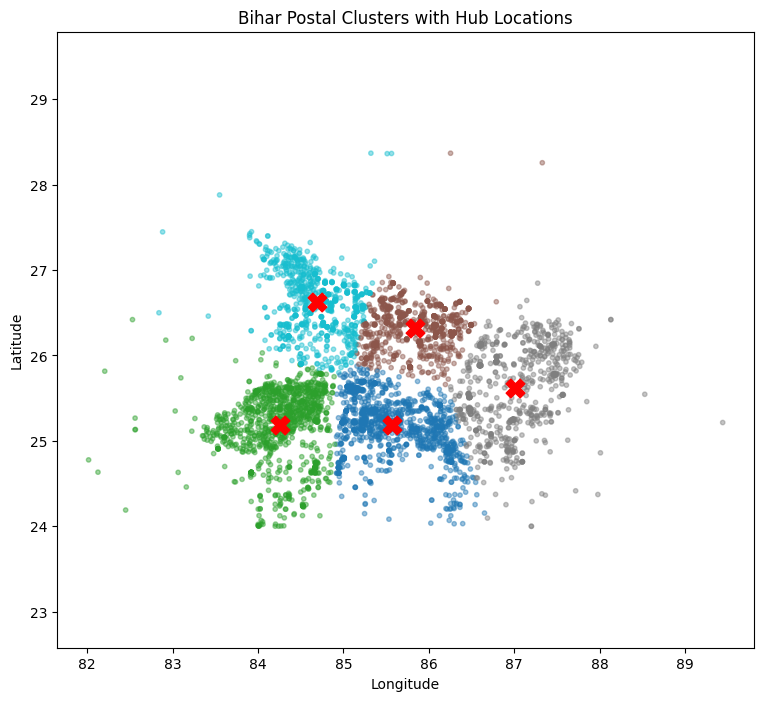

In [52]:
plt.figure(figsize=(9, 8))
plt.scatter(point_longitudes, point_latitudes, c=cluster_tags, cmap="tab10", s=10, alpha=0.45)
plt.scatter(hub_locations[:, 0], hub_locations[:, 1], c="red", marker="X", s=180)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Bihar Postal Clusters with Hub Locations")
plt.axis("equal")
plt.show()


#### Interpretation

The centroids act like candidate postal hub locations for Bihar, and each cluster groups nearby post offices around one hub.

This notebook follows the same overall flow as the reference K-Means notebook, but the variables are renamed, the cleaning steps are clearer, and the Bihar-specific coordinate issues are handled explicitly before clustering.
